In [16]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("/kaggle/input/datasets/thanhluanchimto/source-code")
METADATA_ROOT = Path("/kaggle/input/datasets/thanhluanchimto/meta-data/metadata")
DATA_ROOT = Path("/kaggle/input/datasets/attentionlayer241/celeba-spoof-for-face-antispoofing/CelebA_Spoof_/CelebA_Spoof")
CHECKPOINT_ROOT = (Path("/kaggle/working") / "checkpoints")
REPORT_ROOT = Path("/kaggle/working/reports")
REPORT_ROOT.mkdir(parents=True, exist_ok=True)
sys.path.append(str(PROJECT_ROOT))
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)

sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT.exists())
print(METADATA_ROOT.exists())
print(DATA_ROOT.exists())

True
True
True


In [17]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import time

from torch.utils.data import (DataLoader, random_split)
from torchvision import transforms
from tqdm import tqdm

from src.datasets.celeba_spoof_dataset import (CelebASpoofDataset)
from src.models.fsfm_lite import (FSFMLite)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import transforms
from torch.utils.data import DataLoader

In [18]:
train_df = pd.read_csv(
   METADATA_ROOT
   / "train_df.csv"
)

test_df = pd.read_csv(
   METADATA_ROOT
   / "test_df.csv"
)
DATA_ROOT = Path(
    "/kaggle/input/datasets/attentionlayer241/celeba-spoof-for-face-antispoofing/CelebA_Spoof_/CelebA_Spoof"
)

for df in [train_df, test_df]:

    df["image_path"] = df["image_rel_path"].apply(
        lambda x: str(DATA_ROOT / x)
    )

    df["bb_path"] = df["image_rel_path"].apply(
        lambda x: str(
            DATA_ROOT
            / x.replace(".jpg", "_BB.txt")
               .replace(".png", "_BB.txt")
        )
    )

print(train_df.iloc[0]["image_path"])
print(train_df.iloc[0]["bb_path"])

print(train_df.shape)
print(test_df.shape)

/kaggle/input/datasets/attentionlayer241/celeba-spoof-for-face-antispoofing/CelebA_Spoof_/CelebA_Spoof/Data/train/4980/spoof/000003.jpg
/kaggle/input/datasets/attentionlayer241/celeba-spoof-for-face-antispoofing/CelebA_Spoof_/CelebA_Spoof/Data/train/4980/spoof/000003_BB.txt
(244274, 4)
(25758, 4)


In [19]:
face_transform = transforms.Compose([
   transforms.ToPILImage(),
   transforms.Resize((224,224)),
   transforms.ToTensor(),
   transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

In [20]:
dataset = CelebASpoofDataset(
    train_df,
    transform=face_transform
)
print(len(dataset))

244274


In [21]:
train_size = int(0.9 * len(dataset))
val_size = (len(dataset) - train_size)

train_dataset, val_dataset = random_split(
   dataset,
   [
      train_size,
      val_size
   ]
)

print(len(train_dataset))
print(len(val_dataset))

219846
24428


In [22]:
BATCH_SIZE = 16
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [23]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [24]:
model = FSFMLite()
model = model.to(device)

print("Model Loaded")

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Model Loaded


In [25]:
for p in model.backbone.parameters():
   p.requires_grad = False

trainable_params = sum(
   p.numel()
   for p in model.parameters()
   if p.requires_grad
)

print(f"{trainable_params:,}")

11,420,930


In [26]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Params: {total_params:,}")
print(f"Trainable Params: {trainable_params:,}")

Total Params: 98,001,410
Trainable Params: 11,420,930


In [27]:
criterion = nn.CrossEntropyLoss()

In [28]:
optimizer = torch.optim.AdamW(
   filter(lambda p: p.requires_grad, model.parameters()),
   lr=1e-4,
   weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

In [29]:
def train_one_epoch(model, loader, optimizer, criterion, device):

   model.train()

   total_loss = 0
   total_correct = 0
   total_samples = 0

   pbar = tqdm(loader)

   for batch in pbar:

      images = batch["image"].to(device)
      labels = batch["label"].to(device)

      optimizer.zero_grad()
      logits = model(images)
      loss = criterion(logits, labels)
      pbar.set_postfix(loss=f"{loss.item():.4f}")

      loss.backward()
      torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
      optimizer.step()
      
      preds = logits.argmax(dim=1)
      total_correct += (preds == labels).sum().item()
      total_samples += labels.size(0)
      total_loss += loss.item()

   return (total_loss / len(loader), total_correct / total_samples)

In [30]:
def validate(model, loader, criterion, device):

   model.eval()

   running_loss = 0
   running_correct = 0
   running_total = 0

   with torch.no_grad():

      for batch in loader:
         images = batch["image"].to(device)
         labels = batch["label"].to(device)

         logits = model(images)
         loss = criterion(logits, labels)
         preds = logits.argmax(dim=1)
         running_loss += loss.item()
         running_correct += (preds == labels).sum().item()
         running_total += labels.size(0)

   epoch_loss = (running_loss / len(loader))
   epoch_acc = (running_correct / running_total)
   
   return epoch_loss, epoch_acc

In [31]:
dataset = CelebASpoofDataset(
    train_df,
    transform=face_transform
)

sample = dataset[0]

print(sample["image"].shape)
print(sample["label"])

torch.Size([3, 224, 224])
tensor(1)


In [32]:
batch = next(iter(train_loader))

print(batch["image"].shape)
print(batch["label"].shape)

torch.Size([16, 3, 224, 224])
torch.Size([16])


In [33]:
# EPOCHS = 3
# best_acc = 0

# start_time = time.time()
# for epoch in range(EPOCHS):

#     train_loss, train_acc = train_one_epoch(
#         model,
#         train_loader,
#         optimizer,
#         criterion,
#         device
#     )

#     val_loss, val_acc = validate(
#         model,
#         val_loader,
#         criterion,
#         device
#     )
    
#     scheduler.step(val_acc)
#     current_lr = optimizer.param_groups[0]["lr"]
#     print(f"LR: {current_lr:.6f}")

#     print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
#     print(f"Train Loss: {train_loss:.4f}")
#     print(f"Train Acc : {train_acc:.4f}")
#     print(f"Val Loss   : {val_loss:.4f}")
#     print(f"Val Acc    : {val_acc:.4f}")

#     if val_acc > best_acc:
#         best_acc = val_acc
#         torch.save(
#             {
#                 "epoch": epoch,
#                 "model_state_dict": model.state_dict(),
#                 "optimizer_state_dict": optimizer.state_dict(),
#                 "best_acc": best_acc
#             },
#             CHECKPOINT_ROOT
#             / "best_fsfm_lite.pth"
#         )

#         print("Best Model Saved!")

# print(f"Training Time: {(time.time()-start_time)/60:.2f} min")

In [34]:
test_df = pd.read_csv(METADATA_ROOT / "test_df.csv")
print(test_df.shape)
test_df.head()

(25758, 4)


,image_rel_path,image_path,bb_path,label
0,Data/test/6964/spoof/494405.png,D:\code\FSFM_Lite_Project\data\CelebA_Spoof\Da...,D:\code\FSFM_Lite_Project\data\CelebA_Spoof\Da...,1
1,Data/test/6407/spoof/494411.png,D:\code\FSFM_Lite_Project\data\CelebA_Spoof\Da...,D:\code\FSFM_Lite_Project\data\CelebA_Spoof\Da...,1
2,Data/test/6153/spoof/494412.png,D:\code\FSFM_Lite_Project\data\CelebA_Spoof\Da...,D:\code\FSFM_Lite_Project\data\CelebA_Spoof\Da...,1
3,Data/test/6411/live/494418.png,D:\code\FSFM_Lite_Project\data\CelebA_Spoof\Da...,D:\code\FSFM_Lite_Project\data\CelebA_Spoof\Da...,0
4,Data/test/6336/spoof/494419.png,D:\code\FSFM_Lite_Project\data\CelebA_Spoof\Da...,D:\code\FSFM_Lite_Project\data\CelebA_Spoof\Da...,1


In [35]:
face_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [36]:
test_dataset = CelebASpoofDataset(test_df, transform=face_transform)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

print(len(test_dataset))

25758


In [37]:
checkpoint = torch.load(
    "/kaggle/input/datasets/thanhluanchimto/models/best_fsfm_lite.pth",
    map_location="cpu"
)

print(checkpoint.keys())

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'best_acc'])


In [38]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = FSFMLite()

checkpoint = torch.load(
    "/kaggle/input/datasets/thanhluanchimto/models/best_fsfm_lite.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])

model = model.to(device)
model.eval()

print("Model Loaded")
print("Best Acc:", checkpoint["best_acc"])
print("Epoch:", checkpoint["epoch"])

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Model Loaded
Best Acc: 0.9935729490748322
Epoch: 2


In [ ]:
test_df = pd.read_csv(
    METADATA_ROOT / "test_df.csv"
)

In [ ]:
test_df["image_path"] = test_df["image_rel_path"].apply(
    lambda x: str(DATA_ROOT / x)
)

test_df["bb_path"] = test_df["image_rel_path"].apply(
    lambda x: str(
        DATA_ROOT
        / x.replace(".jpg", "_BB.txt")
           .replace(".png", "_BB.txt")
    )
)

In [ ]:
test_dataset = CelebASpoofDataset(
    test_df,
    transform=face_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

In [51]:
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():

    for batch in tqdm(test_loader):

        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        logits = model(images)

        probs = torch.softmax(logits, dim=1)[:,1]
        preds = logits.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

100%|██████████| 805/805 [24:52<00:00,  1.85s/it]


In [52]:
acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9037
Precision: 0.9884
Recall   : 0.8628
F1 Score : 0.9214


In [53]:
report = classification_report(all_labels, all_preds, target_names=["Live", "Spoof"])

print(report)

with open(
    REPORT_ROOT /
    "classification_report.txt",
    "w"
) as f:

    f.write(report)

              precision    recall  f1-score   support

        Live       0.79      0.98      0.88      8911
       Spoof       0.99      0.86      0.92     16847

    accuracy                           0.90     25758
   macro avg       0.89      0.92      0.90     25758
weighted avg       0.92      0.90      0.91     25758



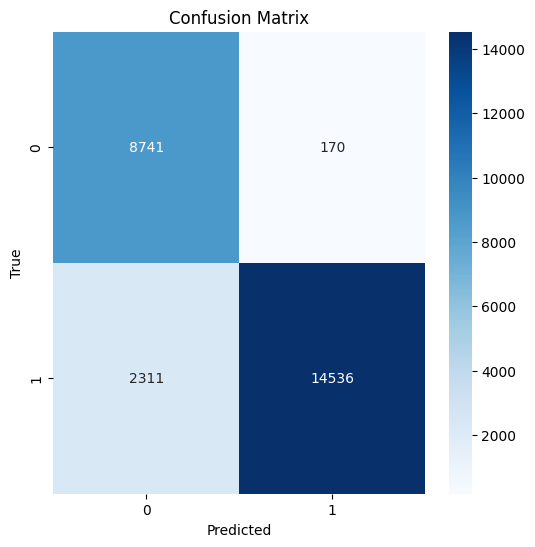

In [54]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.savefig(REPORT_ROOT / "confusion_matrix.png")

plt.show()

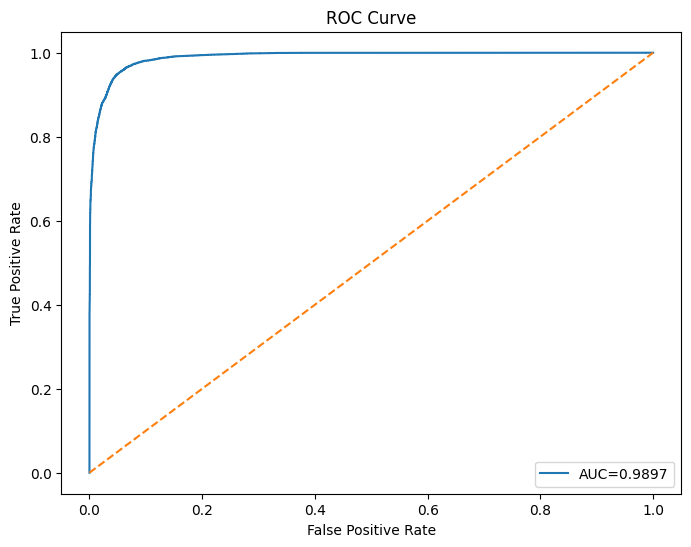

AUC: 0.9897


In [55]:
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr,label=f"AUC={roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig(REPORT_ROOT / "roc_curve.png")

plt.show()

print(f"AUC: {roc_auc:.4f}")

In [56]:
metrics = {
    "accuracy": float(acc),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "auc": float(roc_auc)
}

import json

with open(
    REPORT_ROOT /
    "metrics.json",
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )

metrics

{'accuracy': 0.9036804099697181,
 'precision': 0.9884400924792601,
 'recall': 0.8628242417047546,
 'f1_score': 0.921370392672646,
 'auc': 0.9896955253882539}